In [1]:
import tensorflow as tf
import os

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)

2026-02-13 14:25:55.529279: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 14:25:55.529301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-13 14:25:55.554635: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 14:25:55.609757: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 14:25:56.457256: W tensorflow/compiler/tf2

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-02-13 14:25:57.427173: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-13 14:25:57.575808: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-13 14:25:57.577510: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"           
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"   

In [3]:
import cv2
import imghdr

In [4]:
data_dir = 'data'

In [5]:
image_exts = ['jpeg','jpg','bmp', 'png']

In [6]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# Load Data

In [5]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf

In [8]:
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 1337

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.30,
    subset="training",
)

Found 17933 files belonging to 2 classes.
Using 12554 files for training.


2026-02-13 12:12:47.218492: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-13 12:12:47.220770: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-13 12:12:47.222601: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [10]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    "data",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.30,
    subset="validation",
)

Found 17933 files belonging to 2 classes.
Using 5379 files for validation.


In [11]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
val_batches = int(temp_batches * (2/3))
test_batches = temp_batches - val_batches

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

In [12]:
print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())
print("class names:", train_ds.class_names)

train batches: 393
val batches: 112
test batches: 57
class names: ['happy', 'sad']


 # Preprocess Data

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
def scale(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    y = tf.cast(y, tf.float32) 
    return x, y

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def augment(x, y):
    return data_aug(x, training=True), y

train_ds = train_ds.map(scale, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache("train_cache_96")

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)


In [15]:
temp_ds = temp_ds.map(scale, num_parallel_calls=AUTOTUNE)

val_ds = temp_ds.take(val_batches).cache("val_cache_96").prefetch(AUTOTUNE)
test_ds = temp_ds.skip(val_batches).cache("test_cache_96").prefetch(AUTOTUNE)

# Build Deep learning Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input, GlobalAveragePooling2D,BatchNormalization

In [17]:
model = Sequential([
    Input(shape=(96, 96, 3)),

    Conv2D(16, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    
    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation="sigmoid"),
])

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

In [19]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 96, 96, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 48, 48, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 24, 24, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 12, 12, 64)       

# Train

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

In [31]:
print("train:", train_ds.element_spec)
print("val:", val_ds.element_spec)

x, y = next(iter(train_ds))
print("train batch:", x.shape, y.shape)

xv, yv = next(iter(val_ds))
print("val batch:", xv.shape, yv.shape)

train: (TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
val: (TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
train batch: (32, 96, 96, 3) (32,)
val batch: (32, 96, 96, 3) (32,)


2026-02-13 12:14:43.200231: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2206266575275626515
2026-02-13 12:14:43.200277: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12657768455868151966
2026-02-13 12:14:43.200309: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2206266575275626515
2026-02-13 12:14:43.200319: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12657768455868151966


In [32]:
hist = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/30
393/393 [==============================] - 4s 10ms/step - loss: 0.1431 - accuracy: 0.9446 - auc: 0.9861 - val_loss: 0.1981 - val_accuracy: 0.9213 - val_auc: 0.9751 - lr: 6.2500e-05
Epoch 2/30
393/393 [==============================] - 4s 10ms/step - loss: 0.1362 - accuracy: 0.9477 - auc: 0.9873 - val_loss: 0.1995 - val_accuracy: 0.9238 - val_auc: 0.9753 - lr: 6.2500e-05
Epoch 3/30
393/393 [==============================] - 4s 10ms/step - loss: 0.1405 - accuracy: 0.9462 - auc: 0.9868 - val_loss: 0.1956 - val_accuracy: 0.9216 - val_auc: 0.9757 - lr: 6.2500e-05
Epoch 4/30
393/393 [==============================] - 4s 10ms/step - loss: 0.1368 - accuracy: 0.9469 - auc: 0.9875 - val_loss: 0.1974 - val_accuracy: 0.9227 - val_auc: 0.9752 - lr: 6.2500e-05
Epoch 5/30
393/393 [==============================] - 4s 11ms/step - loss: 0.1384 - accuracy: 0.9453 - auc: 0.9869 - val_loss: 0.2001 - val_accuracy: 0.9230 - val_auc: 0.9753 - lr: 6.2500e-05
Epoch 6/30
393/393 [====================

# Plot Performance

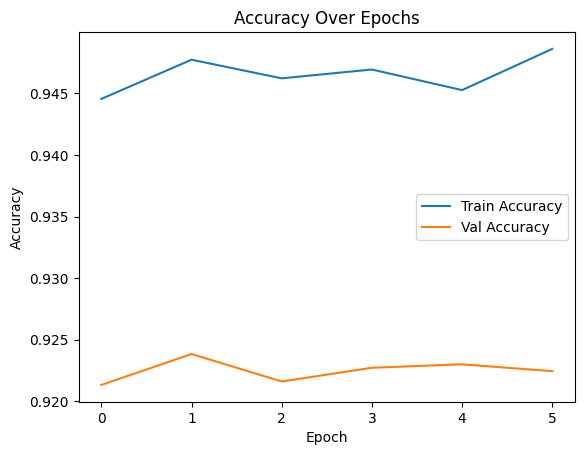

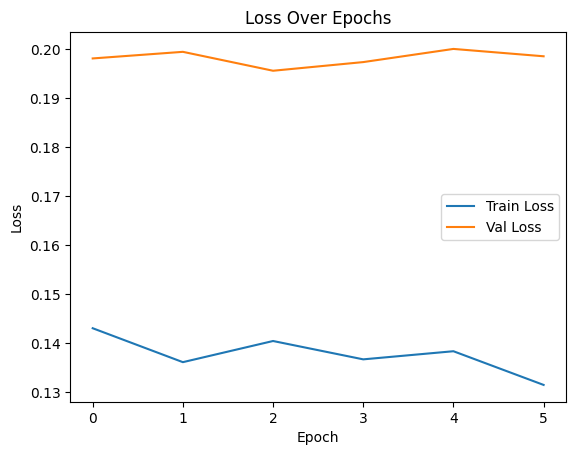

In [67]:
# Accuracy
plt.figure()
plt.plot(hist.history["accuracy"], label="Train Accuracy")
plt.plot(hist.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

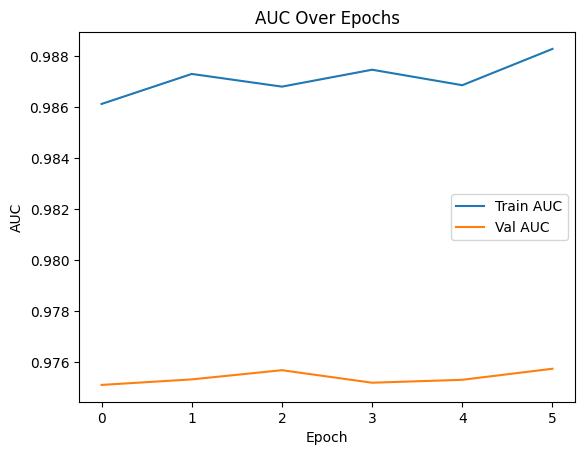

In [68]:
plt.figure()
plt.plot(hist.history["auc"], label="Train AUC")
plt.plot(hist.history["val_auc"], label="Val AUC")
plt.title("AUC Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

# Evaluate

In [12]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy, AUC


In [70]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [71]:
for X, y in test_ds:
    yhat = model.predict(X)
    yhat = (yhat > 0.5).astype(int)

    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 [==============================] - 0s 13ms/step


In [72]:
print("Precision:", pre.result().numpy())
print("Recall:", re.result().numpy())
print("Accuracy:", acc.result().numpy())

Precision: 0.8791045
Recall: 0.9075501
Accuracy: 0.92144847


In [73]:
precision = pre.result().numpy()
recall = re.result().numpy()

f1 = 2 * (precision * recall) / (precision + recall)
print("F1-score:", f1)

F1-score: 0.8931008380625379


# Test

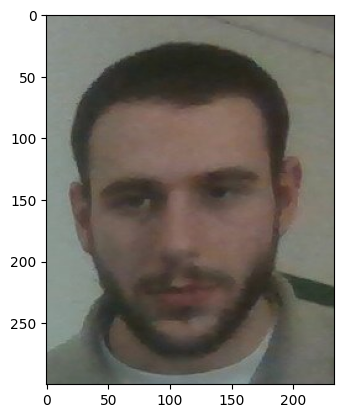

In [6]:
img = cv2.imread('gigi-sad.png')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

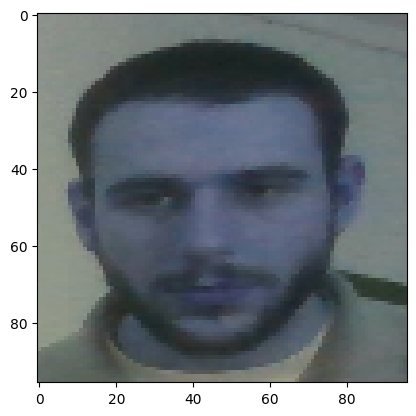

In [13]:
resize = tf.image.resize(img, (96,96))
plt.imshow(resize.numpy().astype(int))


In [14]:
np.expand_dims(resize, 0)

array([[[[143.21875 , 147.21875 , 141.21875 ],
         [138.78125 , 144.78125 , 138.78125 ],
         [136.44336 , 142.44336 , 136.44336 ],
         ...,
         [100.1875  , 109.0625  , 110.0625  ],
         [100.125   , 109.      , 110.      ],
         [ 99.15234 , 108.0625  , 109.0625  ]],

        [[142.09375 , 146.09375 , 140.09375 ],
         [139.84375 , 145.84375 , 139.84375 ],
         [137.40625 , 143.40625 , 137.40625 ],
         ...,
         [106.      , 110.      , 112.      ],
         [106.8125  , 110.8125  , 112.8125  ],
         [105.1875  , 111.625   , 112.8125  ]],

        [[139.40039 , 145.40039 , 139.40039 ],
         [139.3125  , 145.3125  , 139.3125  ],
         [139.3125  , 145.3125  , 139.3125  ],
         ...,
         [107.21875 , 109.7207  , 111.59375 ],
         [104.78125 , 108.15625 , 109.15625 ],
         [104.08789 , 108.08789 , 109.28125 ]],

        ...,

        [[ 96.      , 105.77539 , 103.77539 ],
         [ 98.0625  , 107.21875 , 100.90625 ]

In [15]:
yhat = model.predict(np.expand_dims(resize/255, 0))

2026-02-13 14:27:25.340547: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-02-13 14:27:25.487205: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 1s 1s/step


2026-02-13 14:27:26.556326: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [16]:
yhat

array([[0.87083924]], dtype=float32)

In [17]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


# Save the Model

In [46]:
from tensorflow.keras.models import load_model


In [47]:
model.save("imageclassifier.h5")

/home/pheikara/anaconda3/envs/tf-215-gpu/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [48]:
new_model = load_model('imageclassifier.h5')

# Load Saved Model and test

In [10]:
from tensorflow.keras.models import load_model

model = load_model("imageclassifier.h5")

In [11]:
precision_metric = Precision()
recall_metric    = Recall()
accuracy_metric  = BinaryAccuracy()
auc_metric       = AUC()

NameError: name 'Precision' is not defined

In [51]:
for x_batch, y_batch in test_ds:
    y_pred = model(x_batch, training=False)
    y_pred_binary = tf.cast(y_pred > 0.5, tf.float32)
    precision_metric.update_state(y_batch, y_pred_binary)
    recall_metric.update_state(y_batch, y_pred_binary)
    accuracy_metric.update_state(y_batch, y_pred_binary)
    auc_metric.update_state(y_batch, y_pred)

In [52]:
precision = precision_metric.result().numpy()
recall    = recall_metric.result().numpy()
accuracy  = accuracy_metric.result().numpy()
auc       = auc_metric.result().numpy()

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

In [53]:
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"AUC      : {auc:.4f}")

Accuracy : 92.14%
Precision: 87.91%
Recall   : 90.76%
F1 Score : 89.31%
AUC      : 0.9749
